In [27]:
url = "https://www.ptt.cc/bbs/Tech_Job/index.html"

In [28]:
import requests
from bs4 import BeautifulSoup
import time

def get_tech_job_data(pages=2):
    url = "https://www.ptt.cc/bbs/Tech_Job/index.html"
    headers = {'User-Agent': 'Mozilla/5.0'}
    
    for i in range(pages):
        print(f"--- 正在爬取第 {i+1} 頁 ---")
        res = requests.get(url, headers=headers)
        soup = BeautifulSoup(res.text, 'html.parser')
        
        articles = soup.find_all('div', class_='r-ent')
        
        for art in articles:
            title_div = art.find('div', class_='title')
            
            if not title_div or not title_div.find('a'):
                continue
            
            full_title = title_div.text.strip()
            
            category = "無"
            clean_title = full_title
            
            if "[" in full_title and "]" in full_title:
                category = full_title.split(']')[0].replace('[', '')
                clean_title = full_title.split(']')[-1].strip()
            
            author_div = art.find('div', class_='author')
            author = author_div.text if author_div else "unknown"
            
            print(f"分類: {category:4} | 標題: {clean_title}")

        btns = soup.find_all('a', class_='btn wide')
        for btn in btns:
            if "上頁" in btn.text:
                url = "https://www.ptt.cc" + btn['href']
                break
        
        time.sleep(1)

get_tech_job_data(pages=2)

--- 正在爬取第 1 頁 ---
分類: 公告   | 標題: 板務處理
分類: 心得   | 標題: US灣區 Google Cloud L4 面試
分類: 情報   | 標題: 7/24 第六屆鈣鈦礦技術暨應用論壇在台南
分類: 新聞   | 標題: 捷克工程師投手宣布「全面引退」　WBC後
分類: 討論   | 標題: 緯創調薪
分類: 請益   | 標題: offer請益-桃園系統廠選擇
分類: 新聞   | 標題: 日媒示警：2 奈米洩密案判決出爐，東京
分類: 新聞   | 標題: 近39年新高！主計處估今年首季經濟成長率
分類: 討論   | 標題: 台達開獎
分類: 請益   | 標題: 第一份工作請益
分類: 新聞   | 標題: 鴻海土城廠遭搜索「帶回3人」　最高層級
分類: 心得   | 標題: Offer請益
分類: 問卷   | 標題: 探索台灣民眾的生活選擇 贈$100超商禮券
分類: 請益   | 標題: 想請問ASML台南工廠請益
分類: 請益   | 標題: 上海外派工作機會
分類: Re: 請益 | 標題: 上海外派工作機會
分類: 新聞   | 標題: 超大規模資料中心2026年資本支出將逼近1
分類: 情報   | 標題: 薪資查詢平台
分類: 公告   | 標題: 多重帳號違規處理說明與適用原則
分類: 公告   | 標題: 板務處理
分類: 公告   | 標題: Tech_Job板板規 2026.03.18
--- 正在爬取第 2 頁 ---
分類: 新聞   | 標題: Meta監控員工按鍵動作　訓練AI模型引發簍
分類: 新聞   | 標題: 科技人才最愛公司出爐！台達電橫掃4榜最
分類: 新聞   | 標題: 資通電軍留不住人才！ 國防部曝外界高薪
分類: Re: 討論 | 標題: Claude開始水token
分類: 新聞   | 標題: 千億美元押注AI基礎設施，亞馬遜深化Anth
分類: 新聞   | 標題: 忘了生日就抓狂！年薪2千萬竹科男控妻索
分類: Re: 心得 | 標題: 分享一下台積技術員薪資明細內容
分類: 討論   | 標題: ChatGPT回來了嗎?
分類: 新聞   | 標題: AI 燒錢引爆裁員潮！Meta、微軟裁員優退
分類: 無    | 標題: offer請益-小英
分類: 討論 

In [29]:
import pandas as pd

data_list = get_tech_job_data(pages=2)

if data_list is None or len(data_list) == 0:
    print("工程師'")
    df = pd.DataFrame()
else:
    df = pd.DataFrame(data_list)
    
    df.to_csv("ptt_tech_jobs.csv", index=False, encoding="utf-8-sig")
    print(f"✅ 資料已自動存檔！總共抓取了 {len(df)} 筆資料。")
    
    display(df.head())

--- 正在爬取第 1 頁 ---
分類: 公告   | 標題: 板務處理
分類: 心得   | 標題: US灣區 Google Cloud L4 面試
分類: 情報   | 標題: 7/24 第六屆鈣鈦礦技術暨應用論壇在台南
分類: 新聞   | 標題: 捷克工程師投手宣布「全面引退」　WBC後
分類: 討論   | 標題: 緯創調薪
分類: 請益   | 標題: offer請益-桃園系統廠選擇
分類: 新聞   | 標題: 日媒示警：2 奈米洩密案判決出爐，東京
分類: 新聞   | 標題: 近39年新高！主計處估今年首季經濟成長率
分類: 討論   | 標題: 台達開獎
分類: 請益   | 標題: 第一份工作請益
分類: 新聞   | 標題: 鴻海土城廠遭搜索「帶回3人」　最高層級
分類: 心得   | 標題: Offer請益
分類: 問卷   | 標題: 探索台灣民眾的生活選擇 贈$100超商禮券
分類: 請益   | 標題: 想請問ASML台南工廠請益
分類: 請益   | 標題: 上海外派工作機會
分類: Re: 請益 | 標題: 上海外派工作機會
分類: 新聞   | 標題: 超大規模資料中心2026年資本支出將逼近1
分類: 情報   | 標題: 薪資查詢平台
分類: 公告   | 標題: 多重帳號違規處理說明與適用原則
分類: 公告   | 標題: 板務處理
分類: 公告   | 標題: Tech_Job板板規 2026.03.18
--- 正在爬取第 2 頁 ---
分類: 新聞   | 標題: Meta監控員工按鍵動作　訓練AI模型引發簍
分類: 新聞   | 標題: 科技人才最愛公司出爐！台達電橫掃4榜最
分類: 新聞   | 標題: 資通電軍留不住人才！ 國防部曝外界高薪
分類: Re: 討論 | 標題: Claude開始水token
分類: 新聞   | 標題: 千億美元押注AI基礎設施，亞馬遜深化Anth
分類: 新聞   | 標題: 忘了生日就抓狂！年薪2千萬竹科男控妻索
分類: Re: 心得 | 標題: 分享一下台積技術員薪資明細內容
分類: 討論   | 標題: ChatGPT回來了嗎?
分類: 新聞   | 標題: AI 燒錢引爆裁員潮！Meta、微軟裁員優退
分類: 無    | 標題: offer請益-小英
分類: 討論 

In [30]:
import requests

def send_line_notification(message):
    token = "你的LINE_NOTIFY_TOKEN" 
    headers = {"Authorization": "Bearer " + token}
    data = {"message": message}
    
    try:
        response = requests.post(
            "https://notify-api.line.me/api/notify", 
            headers=headers, 
            data=data,
            timeout=5 
        )
        if response.status_code == 200:
            print("LINE 通知發送成功！")
        else:
            print(f"發送失敗，錯誤碼：{response.status_code}")
    except Exception as e:
        print(f"網路連線發生錯誤：{e}")

clean_title = "【徵才】知名企業誠徵 工程師"

if "工程師" in clean_title:
    send_line_notification(f"發現關鍵字職缺：{clean_title}")

網路連線發生錯誤：HTTPSConnectionPool(host='notify-api.line.me', port=443): Max retries exceeded with url: /api/notify (Caused by NameResolutionError("HTTPSConnection(host='notify-api.line.me', port=443): Failed to resolve 'notify-api.line.me' ([Errno 11001] getaddrinfo failed)"))


In [31]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def get_ptt_data(pages=2):
    all_data = [] 
    
    url = "https://www.ptt.cc/bbs/Tech_Job/index.html"
    headers = {'User-Agent': 'Mozilla/5.0'}

    for i in range(pages):
        res = requests.get(url, headers=headers)
        soup = BeautifulSoup(res.text, 'html.parser')
        articles = soup.find_all('div', class_='r-ent')

        for art in articles:
            title_div = art.find('div', class_='title')
            if not title_div.find('a'): continue

            full_title = title_div.text.strip()
            
            category = "無"
            clean_title = full_title
            if "[" in full_title and "]" in full_title:
                category = full_title.split(']')[0].replace('[', '')
                clean_title = full_title.split(']')[-1].strip()
            
            author = art.find('div', class_='author').text
            date = art.find('div', class_='date').text

            all_data.append({
                "分類": category,
                "標題": clean_title,
                "作者": author,
                "日期": date
            })

        btns = soup.find_all('a', class_='btn wide')
        for btn in btns:
            if "上頁" in btn.text:
                url = "https://www.ptt.cc" + btn['href']
                break
        time.sleep(1)

    df = pd.DataFrame(all_data)
    return df

df_result = get_ptt_data(pages=3) 
df_result.to_csv("ptt_tech_jobs_multi.csv", index=False, encoding="utf-8-sig")
print(f"成功抓取 {len(df_result)} 筆資料並已存檔！")

成功抓取 61 筆資料並已存檔！


✅ 科技版資料統計成功：
分類
問卦    2
心得    2
情報    1
公告    1
Name: count, dtype: int64


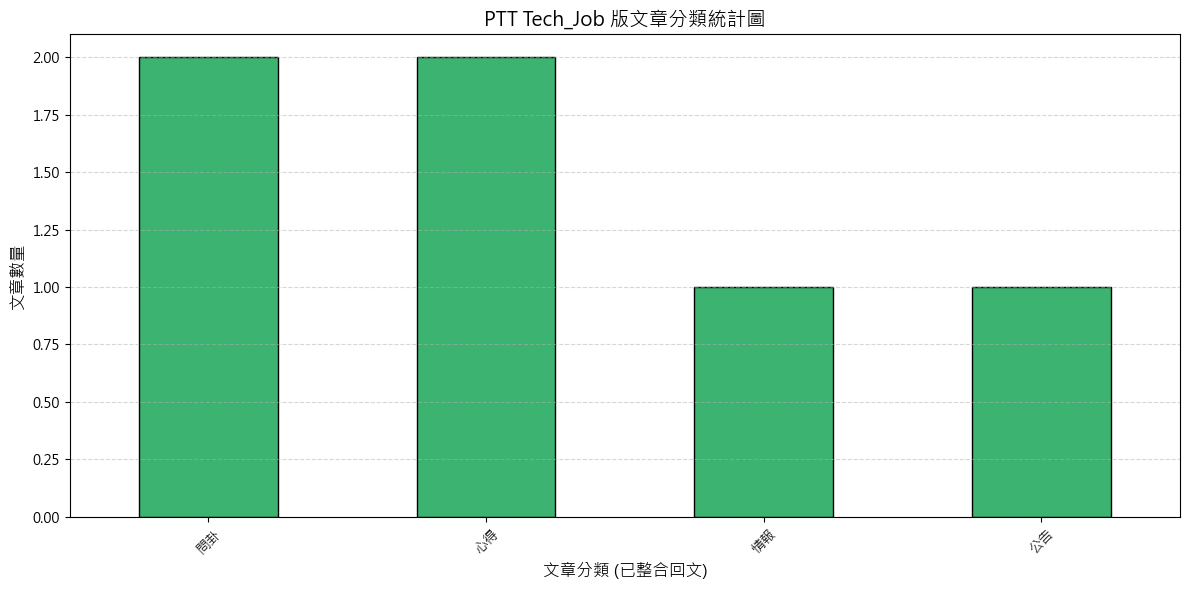

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

if 'all_data' not in locals():
    print("⚠️ 偵測到 'all_data' 尚未定義，已為您產生 Tech_Job 版模擬資料。")
    all_data = [
        {"分類": "新聞", "標題": "科技業景氣寒冬？"}, {"分類": "請益", "標題": "台積電面試請益"},
        {"分類": "討論", "標題": "關於分紅大家怎麼看"}, {"分類": "新聞", "標題": "新創公司加薪潮"},
        {"分類": "請益", "標題": "Offer 選擇 N vs M"}, {"分類": "公告", "標題": "板規更新"},
        {"分類": "心得", "標題": "三年轉職心得分享"}, {"分類": "問卷", "標題": "薪資調查問卷"},
        {"分類": "Re: 討論", "標題": "回覆：分紅大家怎麼看"}, {"分類": "無", "標題": "單純發文"}
    ]

df = pd.DataFrame(all_data)
df.columns = df.columns.str.strip()

if "分類" in df.columns:
    df['分類'] = df['分類'].str.strip().str.replace('Re: ', '', regex=False)
    
    category_counts = df["分類"].value_counts()
    print("✅ 科技版資料統計成功：")
    print(category_counts)
else:
    print(f"❌ 錯誤：找不到 '分類' 欄位。目前欄位有：{list(df.columns)}")
    category_counts = pd.Series(dtype=int)

if not category_counts.empty:
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(12, 6))

    category_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black')

    plt.title("PTT Tech_Job 版文章分類統計圖", fontsize=14)
    plt.xlabel("文章分類 (已整合回文)", fontsize=12)
    plt.ylabel("文章數量", fontsize=12)
    plt.xticks(rotation=45) 
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()